In [1]:
import os
import pandas as pd
import numpy as np

from pyspark import SparkConf, SparkContext
from pyspark.sql import SparkSession, SQLContext

from pyspark.sql.types import *
import pyspark.sql.functions as F
from pyspark.sql.functions import udf, col

from pyspark.ml.regression import LinearRegression
from pyspark.mllib.evaluation import RegressionMetrics

from pyspark.ml.tuning import ParamGridBuilder, CrossValidator, CrossValidatorModel
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.evaluation import RegressionEvaluator

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
spark = SparkSession.builder.appName("Linear-Regression-California-Housing").master("local").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/01 17:03:51 WARN Utils: Your hostname, charis-Inspiron-15-3511, resolves to a loopback address: 127.0.1.1; using 10.245.119.13 instead (on interface wlp1s0)
26/04/01 17:03:51 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/01 17:04:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
from sklearn.datasets import fetch_california_housing
df = fetch_california_housing()
print(df.data.shape, df.target.shape)

(20640, 8) (20640,)


In [5]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Φόρτωσε το dataset
cal_housing = fetch_california_housing()

df = pd.DataFrame(cal_housing.data, columns=cal_housing.feature_names)

df['MedHouseVal'] = cal_housing.target

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [6]:
df = spark.createDataFrame(df).cache()
df.show(5)

26/04/01 17:06:08 WARN TaskSetManager: Stage 0 contains a task of very large size (1703 KiB). The maximum recommended task size is 1000 KiB.


+------+--------+------------------+------------------+----------+------------------+--------+---------+-----------+
|MedInc|HouseAge|          AveRooms|         AveBedrms|Population|          AveOccup|Latitude|Longitude|MedHouseVal|
+------+--------+------------------+------------------+----------+------------------+--------+---------+-----------+
|8.3252|    41.0| 6.984126984126984|1.0238095238095237|     322.0|2.5555555555555554|   37.88|  -122.23|      4.526|
|8.3014|    21.0| 6.238137082601054|0.9718804920913884|    2401.0| 2.109841827768014|   37.86|  -122.22|      3.585|
|7.2574|    52.0| 8.288135593220339| 1.073446327683616|     496.0|2.8022598870056497|   37.85|  -122.24|      3.521|
|5.6431|    52.0|5.8173515981735155|1.0730593607305936|     558.0| 2.547945205479452|   37.85|  -122.25|      3.413|
|3.8462|    52.0| 6.281853281853282|1.0810810810810811|     565.0|2.1814671814671813|   37.85|  -122.25|      3.422|
+------+--------+------------------+------------------+---------

In [9]:
df.columns

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude',
 'MedHouseVal']

In [10]:
df.printSchema()

root
 |-- MedInc: double (nullable = true)
 |-- HouseAge: double (nullable = true)
 |-- AveRooms: double (nullable = true)
 |-- AveBedrms: double (nullable = true)
 |-- Population: double (nullable = true)
 |-- AveOccup: double (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- MedHouseVal: double (nullable = true)



In [11]:
df.count()

26/04/01 17:14:32 WARN TaskSetManager: Stage 1 contains a task of very large size (1703 KiB). The maximum recommended task size is 1000 KiB.


20640

In [12]:
print('Data frame describe (string and numeric columns only):')
spark.conf.set("spark.sql.debug.maxToStringFields", 1000)
df.describe().toPandas()

print(f'There are total {df.count()} row, Let print first 2 data rows:')
df.limit(2).toPandas()

Data frame describe (string and numeric columns only):


26/04/01 17:14:33 WARN TaskSetManager: Stage 4 contains a task of very large size (1703 KiB). The maximum recommended task size is 1000 KiB.


There are total 20640 row, Let print first 2 data rows:


26/04/01 17:14:34 WARN TaskSetManager: Stage 7 contains a task of very large size (1703 KiB). The maximum recommended task size is 1000 KiB.
26/04/01 17:14:34 WARN TaskSetManager: Stage 10 contains a task of very large size (1703 KiB). The maximum recommended task size is 1000 KiB.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.02381,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.97188,2401.0,2.109842,37.86,-122.22,3.585


In [13]:
df.describe()

DataFrame[summary: string, MedInc: string, HouseAge: string, AveRooms: string, AveBedrms: string, Population: string, AveOccup: string, Latitude: string, Longitude: string, MedHouseVal: string]

In [14]:
result_df = df.groupBy("HouseAge").count().sort("HouseAge", ascending=False)
result_df.show(10)

26/04/01 17:14:35 WARN TaskSetManager: Stage 11 contains a task of very large size (1703 KiB). The maximum recommended task size is 1000 KiB.


+--------+-----+
|HouseAge|count|
+--------+-----+
|    52.0| 1273|
|    51.0|   48|
|    50.0|  136|
|    49.0|  134|
|    48.0|  177|
|    47.0|  198|
|    46.0|  245|
|    45.0|  294|
|    44.0|  356|
|    43.0|  353|
+--------+-----+
only showing top 10 rows


26/04/01 17:14:35 WARN TaskSetManager: Stage 14 contains a task of very large size (1703 KiB). The maximum recommended task size is 1000 KiB.


<Axes: xlabel='HouseAge'>

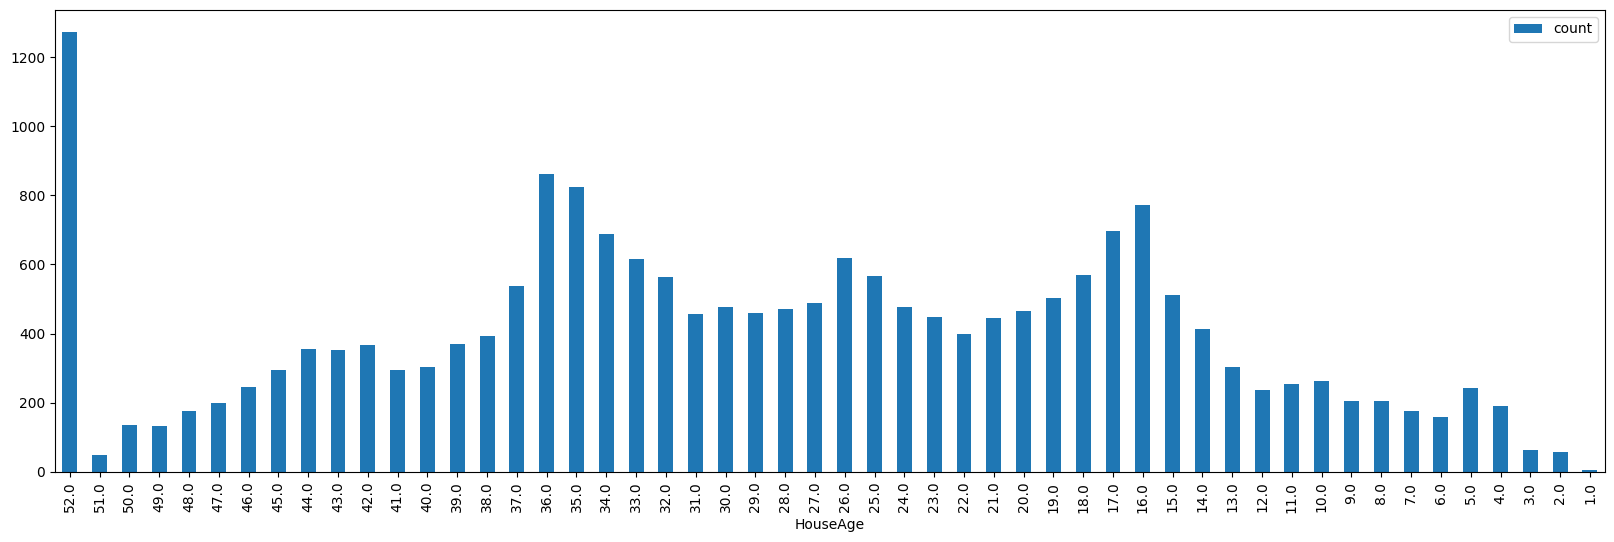

In [15]:
result_df.toPandas().plot.bar(x='HouseAge',figsize = (20,6))

In [16]:
(df.describe().select(
                    "summary",
                    F.round("MedInc", 4).alias("MedInc"),
                    F.round("HouseAge", 4).alias("HouseAge"),
                    F.round("AveRooms", 4).alias("AveRooms"),
                    F.round("AveBedrms", 4).alias("AveBedrms"),
                    F.round("Population", 4).alias("Population"),
                    F.round("AveOccup", 4).alias("AveOccup"),
                    F.round("Latitude", 4).alias("Latitude"),
                    F.round("Longitude",4).alias("Longitude"),
                    F.round("MedHouseVal",4).alias("MedHouseVal"))
                    .show())

26/04/01 17:14:36 WARN TaskSetManager: Stage 22 contains a task of very large size (1703 KiB). The maximum recommended task size is 1000 KiB.


+-------+-------+--------+--------+---------+----------+---------+--------+---------+-----------+
|summary| MedInc|HouseAge|AveRooms|AveBedrms|Population| AveOccup|Latitude|Longitude|MedHouseVal|
+-------+-------+--------+--------+---------+----------+---------+--------+---------+-----------+
|  count|20640.0| 20640.0| 20640.0|  20640.0|   20640.0|  20640.0| 20640.0|  20640.0|    20640.0|
|   mean| 3.8707| 28.6395|   5.429|   1.0967| 1425.4767|   3.0707| 35.6319|-119.5697|     2.0686|
| stddev| 1.8998| 12.5856|  2.4742|   0.4739| 1132.4621|   10.386|   2.136|   2.0035|      1.154|
|    min| 0.4999|     1.0|  0.8462|   0.3333|       3.0|   0.6923|   32.54|  -124.35|       0.15|
|    max|15.0001|    52.0|141.9091|  34.0667|   35682.0|1243.3333|   41.95|  -114.31|        5.0|
+-------+-------+--------+--------+---------+----------+---------+--------+---------+-----------+



Feature Engineering

In [ ]:
# Preprocess the Target value
df = df.withColumn('MedHouseVal',col('MedHouseVal')/100000)
df.show(5)

+------+--------+------------------+------------------+----------+------------------+--------+---------+--------------------+
|MedInc|HouseAge|          AveRooms|         AveBedrms|Population|          AveOccup|Latitude|Longitude|         MedHouseVal|
+------+--------+------------------+------------------+----------+------------------+--------+---------+--------------------+
|8.3252|    41.0| 6.984126984126984|1.0238095238095237|     322.0|2.5555555555555554|   37.88|  -122.23|           4.526E-15|
|8.3014|    21.0| 6.238137082601054|0.9718804920913884|    2401.0| 2.109841827768014|   37.86|  -122.22|           3.585E-15|
|7.2574|    52.0| 8.288135593220339| 1.073446327683616|     496.0|2.8022598870056497|   37.85|  -122.24|3.520999999999999...|
|5.6431|    52.0|5.8173515981735155|1.0730593607305936|     558.0| 2.547945205479452|   37.85|  -122.25|           3.413E-15|
|3.8462|    52.0| 6.281853281853282|1.0810810810810811|     565.0|2.1814671814671813|   37.85|  -122.25|           3.4

26/04/01 17:41:46 WARN TaskSetManager: Stage 26 contains a task of very large size (1703 KiB). The maximum recommended task size is 1000 KiB.


In [21]:
df.columns

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude',
 'MedHouseVal']

Put every feature into a vector format.

In [23]:
# put features into a feature vector column
assembler = VectorAssembler(inputCols=df.columns, outputCol="features") 

In [24]:
assembled_df = assembler.transform(df)

In [ ]:
assembled_df.show(6)

26/04/01 18:55:51 WARN TaskSetManager: Stage 27 contains a task of very large size (1703 KiB). The maximum recommended task size is 1000 KiB.


+------+--------+------------------+------------------+----------+------------------+--------+---------+--------------------+--------------------+
|MedInc|HouseAge|          AveRooms|         AveBedrms|Population|          AveOccup|Latitude|Longitude|         MedHouseVal|            features|
+------+--------+------------------+------------------+----------+------------------+--------+---------+--------------------+--------------------+
|8.3252|    41.0| 6.984126984126984|1.0238095238095237|     322.0|2.5555555555555554|   37.88|  -122.23|           4.526E-15|[8.3252,41.0,6.98...|
|8.3014|    21.0| 6.238137082601054|0.9718804920913884|    2401.0| 2.109841827768014|   37.86|  -122.22|           3.585E-15|[8.3014,21.0,6.23...|
|7.2574|    52.0| 8.288135593220339| 1.073446327683616|     496.0|2.8022598870056497|   37.85|  -122.24|3.520999999999999...|[7.2574,52.0,8.28...|
|5.6431|    52.0|5.8173515981735155|1.0730593607305936|     558.0| 2.547945205479452|   37.85|  -122.25|           3.4

In [27]:
from pyspark.ml.feature import StandardScaler
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")
# Fit the DataFrame to the scaler
scaled_df = scaler.fit(assembled_df).transform(assembled_df)

scaled_df.show(5)

26/04/01 19:03:54 WARN TaskSetManager: Stage 28 contains a task of very large size (1703 KiB). The maximum recommended task size is 1000 KiB.


+------+--------+------------------+------------------+----------+------------------+--------+---------+--------------------+--------------------+--------------------+
|MedInc|HouseAge|          AveRooms|         AveBedrms|Population|          AveOccup|Latitude|Longitude|         MedHouseVal|            features|      scaledFeatures|
+------+--------+------------------+------------------+----------+------------------+--------+---------+--------------------+--------------------+--------------------+
|8.3252|    41.0| 6.984126984126984|1.0238095238095237|     322.0|2.5555555555555554|   37.88|  -122.23|           4.526E-15|[8.3252,41.0,6.98...|[4.38209539419522...|
|8.3014|    21.0| 6.238137082601054|0.9718804920913884|    2401.0| 2.109841827768014|   37.86|  -122.22|           3.585E-15|[8.3014,21.0,6.23...|[4.36956790291791...|
|7.2574|    52.0| 8.288135593220339| 1.073446327683616|     496.0|2.8022598870056497|   37.85|  -122.24|3.520999999999999...|[7.2574,52.0,8.28...|[3.82004265529

26/04/01 19:03:55 WARN TaskSetManager: Stage 31 contains a task of very large size (1703 KiB). The maximum recommended task size is 1000 KiB.


Build Machine Learning Model

In [38]:
train_df, test_df = scaled_df.randomSplit(weights=[0.8,0.2], seed=42)

In [39]:
train_df.columns

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude',
 'MedHouseVal',
 'features',
 'scaledFeatures']

In [44]:
from pyspark.ml.regression import LinearRegression

# Initialize `lr`
lr = (LinearRegression(labelCol="MedHouseVal"))
# Fit the data to the model
linearModel = lr.fit(train_df)

26/04/01 19:29:27 WARN Instrumentation: [ba10e02a] regParam is zero, which might cause numerical instability and overfitting.
26/04/01 19:29:28 WARN TaskSetManager: Stage 34 contains a task of very large size (1703 KiB). The maximum recommended task size is 1000 KiB.
26/04/01 19:29:28 WARN TaskSetManager: Stage 35 contains a task of very large size (1703 KiB). The maximum recommended task size is 1000 KiB.


In [45]:
# Print the coefficients and intercept for linear regression
print("Coefficients: {}".format(linearModel.coefficients))
print('Intercept: {}'.format(linearModel.intercept))

Coefficients: [-2.8812839510768907e-30,-2.450598128576075e-31,4.104300478078744e-30,-1.5797203809482765e-29,-6.647493473462123e-34,3.584624824412005e-32,-1.094329537557194e-29,-1.1679491529189869e-29,0.999999999999998]
Intercept: -9.88412115262026e-28


In [47]:
test_results = linearModel.evaluate(test_df)

#Printing Residuals which is the difference between the actua
#l value and the value predicted by the model (y-ŷ) for any given point
test_results.residuals.show(5)

26/04/01 19:30:04 WARN TaskSetManager: Stage 36 contains a task of very large size (1703 KiB). The maximum recommended task size is 1000 KiB.


+--------------------+
|           residuals|
+--------------------+
|-2.66240555512091...|
|-2.95822839457879...|
|-1.00579765415679...|
|1.972152263052529...|
|-2.95822839457879...|
+--------------------+
only showing top 5 rows


26/04/01 19:30:05 WARN TaskSetManager: Stage 37 contains a task of very large size (1703 KiB). The maximum recommended task size is 1000 KiB.


In [48]:
unlabeled_data = test_df.select('features')

predictions = linearModel.transform(unlabeled_data)
predictions.show(5)

+--------------------+--------------------+
|            features|          prediction|
+--------------------+--------------------+
|[0.4999,16.0,21.6...|7.350000000000027...|
|[0.4999,36.0,2.5,...|1.625000000000002...|
|[0.4999,46.0,1.71...|6.750000000000101...|
|[0.536,16.0,2.111...|1.62499999999998E-15|
|[0.536,46.0,3.142...|8.750000000000002...|
+--------------------+--------------------+
only showing top 5 rows


26/04/01 19:30:35 WARN TaskSetManager: Stage 38 contains a task of very large size (1703 KiB). The maximum recommended task size is 1000 KiB.


In [49]:
print("RMSE: {}".format(test_results.rootMeanSquaredError))
print("MSE: {}".format(test_results.meanSquaredError))

RMSE: 7.654941063954828e-30
MSE: 5.859812269262188e-59


In [52]:
print("R2:".format(linearModel.summary.r2))

R2:
